# HH-PC vs LIF-PC: Timestep Sweep Evaluation

Extends `hhpc_base.py` (the trimmed HH-only, MNIST/FMNIST-only base) back out to:

- **3 datasets**: MNIST, FashionMNIST, N-MNIST (neuromorphic, event-based)
- **2 neuron models**: Hodgkin-Huxley (`HHNeuron`, from the base file) and a
  Leaky Integrate-and-Fire (`LIFNeuron`, added here — it isn't in the trimmed
  base since it was ablation-only) with the same PC training/inference code
- **Timestep sweep**: `steps_spk` from 10 to 70 (step of 10)

Everything neuron-agnostic (PC inference, PC learning, metrics, training loop)
is carried over from `hhpc_base.py` unchanged. What's new:

1. `LIFNeuron` — added back so HH can be compared against a LIF baseline.
2. N-MNIST loading via `tonic`, converted to fixed-length frame sequences so
   its timestep count matches `steps_spk` for a given sweep point.
3. `PCSNNet.forward_proxies` now accepts either a static image (encoded into
   spikes internally, as before) **or** a pre-binned event tensor `[B, D, T]`
   (N-MNIST), which it uses directly as the spike train.
4. A resumable sweep driver that trains HH-PC and LIF-PC at every
   `(dataset, steps_spk)` point and logs results to CSV.

**Compute note:** the full sweep is 3 datasets × 7 timestep values × 2 neuron
types = **42 training runs**. At ~10 epochs each this is a multi-hour job on
GPU. Set `QUICK_TEST = True` in the config cell for a fast smoke test first,
and use a GPU runtime (the sweep resumes from `RESULTS_CSV` if interrupted).

**N-MNIST on Kaggle:** if running on Kaggle, turn on internet access in the
notebook settings so `tonic` can download N-MNIST on first use.

## 0. Setup

In [1]:
import subprocess, sys

def pip_install(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

# --no-deps => pip never touches numpy, so no restart is needed.
# tonic 1.6.0 *declares* numpy<2.0.0 in its metadata, but the code paths this
# notebook uses do not actually need numpy 1.x.
# pbr and importRosbag are the only two deps tonic imports at import-time that
# Kaggle doesn't already ship. numpy/scipy/h5py/tqdm/pandas/matplotlib are preinstalled.
pip_install("--no-deps", "tonic==1.6.0", "pbr", "importRosbag")

import numpy as np
# harmless safety net in case any dependency still reaches for a numpy-1 alias
for old, new in [("float_", "float64"), ("int_", "int64"), ("bool8", "bool_")]:
    if not hasattr(np, old):
        setattr(np, old, getattr(np, new))

import tonic
print("numpy:", np.__version__, "| tonic:", tonic.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 10.5 MB/s eta 0:00:00
numpy: 2.0.2 | tonic: 1.6.0


In [2]:
import os
import json
import time
from typing import List, Optional, Dict, Any, Tuple

import numpy as np
import torch
from tqdm.auto import tqdm

import tonic
import tonic.transforms as tonic_transforms

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm.auto import tqdm

import tonic
import tonic.transforms as tonic_transforms

import pandas as pd
import matplotlib.pyplot as plt

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cu128 | CUDA available: True


## 1. Utilities

In [3]:
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def default_device():
    return "cuda" if torch.cuda.is_available() else "cpu"


def one_hot(y: torch.Tensor, num_classes: int) -> torch.Tensor:
    return F.one_hot(y.long(), num_classes=num_classes).float()


def prepare_batch(x: torch.Tensor) -> torch.Tensor:
    """Flatten a batch for the network.

    Static images arrive as [B, C, H, W] -> flattened to [B, D].
    Pre-binned N-MNIST event frames arrive as [B, T, C, H, W] and are
    kept as [B, D, T] so PCSNNet treats time as already-encoded spikes.
    """
    if x.dim() == 5:  # [B, T, C, H, W] event frames
        B, T = x.size(0), x.size(1)
        return x.reshape(B, T, -1).permute(0, 2, 1).contiguous()
    return x.reshape(x.size(0), -1)

## 2. Data loaders (MNIST / FMNIST / N-MNIST)

MNIST and FMNIST are loaded via `torchvision` exactly as in the base file —
raw pixel intensities in `[0, 1]`, encoded into spikes *inside* the network
(Poisson or latency-first) at whatever `steps_spk` the sweep is using.

N-MNIST is different: it's already a temporal event stream. `tonic.ToFrame`
bins each recording into exactly `n_time_bins == steps_spk` frames of shape
`(T, 2, 34, 34)` (2 polarity channels), which are binarized to `{0, 1}` and
fed to the network as an already-encoded spike train — no internal encoding
needed. Frames are cached to disk per `steps_spk` value with
`tonic.DiskCachedDataset` since re-decoding raw events every epoch is slow.

In [4]:
DATASET_INPUT_DIMS = {"MNIST": 28 * 28, "FMNIST": 28 * 28, "NMNIST": 34 * 34 * 2}
NUM_CLASSES = 10


def _get_static_loaders(dataset_name, batch_size, root, device, val_ratio, seed):
    tfm = transforms.Compose([transforms.ToTensor()])
    ds = dataset_name.upper()
    if ds in ("FMNIST", "FASHIONMNIST"):
        train_full = datasets.FashionMNIST(root=root, train=True, download=True, transform=tfm)
        test_ds = datasets.FashionMNIST(root=root, train=False, download=True, transform=tfm)
    else:
        train_full = datasets.MNIST(root=root, train=True, download=True, transform=tfm)
        test_ds = datasets.MNIST(root=root, train=False, download=True, transform=tfm)

    n_total = len(train_full)
    n_val = max(1, int(round(val_ratio * n_total)))
    n_train = n_total - n_val
    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=g)

    use_cuda = device.startswith("cuda") and torch.cuda.is_available()
    kw = dict(num_workers=2 if use_cuda else 0, pin_memory=use_cuda)
    return (
        DataLoader(train_ds, batch_size, shuffle=True, **kw),
        DataLoader(val_ds, batch_size, shuffle=False, **kw),
        DataLoader(test_ds, batch_size, shuffle=False, **kw),
    )


def _binarize_frames(frames):
    return (frames > 0).astype(np.uint8)


def _nmnist_collate(batch):
    xs, ys = zip(*batch)
    xs = torch.stack([torch.as_tensor(x) for x in xs]).float()  # [B, T, C, H, W], binarized
    ys = torch.tensor(ys, dtype=torch.long)
    return xs, ys


def _get_nmnist_loaders(batch_size, root, steps_spk, val_ratio, seed, device):
    sensor_size = tonic.datasets.NMNIST.sensor_size
    frame_tfm = tonic_transforms.Compose([
        tonic_transforms.Denoise(filter_time=10000),
        tonic_transforms.ToFrame(sensor_size=sensor_size, n_time_bins=steps_spk),
        _binarize_frames,
    ])

    train_raw = tonic.datasets.NMNIST(save_to=root, train=True, transform=frame_tfm)
    test_raw = tonic.datasets.NMNIST(save_to=root, train=False, transform=frame_tfm)

    cache_root = os.path.join(root, "nmnist_cache", f"T{steps_spk}")
    train_full = tonic.DiskCachedDataset(train_raw, cache_path=os.path.join(cache_root, "train"))
    test_ds = tonic.DiskCachedDataset(test_raw, cache_path=os.path.join(cache_root, "test"))

    n_total = len(train_full)
    n_val = max(1, int(round(val_ratio * n_total)))
    n_train = n_total - n_val
    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=g)

    use_cuda = device.startswith("cuda") and torch.cuda.is_available()
    kw = dict(num_workers=2 if use_cuda else 0, pin_memory=use_cuda, collate_fn=_nmnist_collate)
    return (
        DataLoader(train_ds, batch_size, shuffle=True, **kw),
        DataLoader(val_ds, batch_size, shuffle=False, **kw),
        DataLoader(test_ds, batch_size, shuffle=False, **kw),
    )


def get_loaders(dataset_name="MNIST", batch_size=128, root="./data", device="cpu",
                val_ratio=0.1, seed=42, steps_spk=50):
    ds = dataset_name.upper()
    if ds == "NMNIST":
        return _get_nmnist_loaders(batch_size, root, steps_spk, val_ratio, seed, device)
    return _get_static_loaders(dataset_name, batch_size, root, device, val_ratio, seed)

## 3. Hodgkin-Huxley neuron (unchanged from `hhpc_base.py`)

In [5]:
class HHNeuron(nn.Module):
    class Gate:
        def __init__(self, B, N, device):
            self.alpha = torch.zeros(B, N, device=device)
            self.beta = torch.zeros(B, N, device=device)
            self.state = torch.zeros(B, N, device=device)

        def update(self, dt):
            s = self.state + dt * (self.alpha * (1 - self.state) - self.beta * self.state)
            return s.clamp(0.0, 1.0)

        def set_inf(self):
            self.state = self.alpha / (self.alpha + self.beta + 1e-8)

    def __init__(self, N, dt=0.03, device="cpu", thr=0.8, reset=0.0, tau_ref=2.0):
        super().__init__()
        self.N, self.dt, self.device = N, float(dt), device
        self.thr, self.reset = float(thr), float(reset)
        self.refr_steps = max(1, int(round(tau_ref / dt)))
        for name, val in [("ENa", 115.), ("EK", -12.), ("Eleak", 10.6),
                           ("gNa", 120.), ("gK", 36.), ("gLeak", 0.3), ("Cm", 1.)]:
            self.register_buffer(name, torch.tensor(val))
        self.reset_states(1)

    def reset_states(self, B):
        dev = self.device
        self.B = B
        self.Vm = torch.zeros(B, self.N, device=dev)
        self.m = HHNeuron.Gate(B, self.N, dev)
        self.n = HHNeuron.Gate(B, self.N, dev)
        self.h = HHNeuron.Gate(B, self.N, dev)
        self._update_gates(self.Vm)
        self.m.set_inf(); self.n.set_inf(); self.h.set_inf()
        self.refr = torch.zeros(B, self.N, device=dev)

    def _update_gates(self, V):
        V = V.clamp(-100., 100.)
        self.n.alpha = 0.01 * (10 - V) / (torch.exp((10 - V) / 10) - 1 + 1e-8)
        self.n.beta = 0.125 * torch.exp(-V / 80.)
        self.m.alpha = 0.1 * (25 - V) / (torch.exp((25 - V) / 10) - 1 + 1e-8)
        self.m.beta = 4. * torch.exp(-V / 18.)
        self.h.alpha = 0.07 * torch.exp(-V / 20.)
        self.h.beta = 1. / (torch.exp((30 - V) / 10) + 1.)

    def forward(self, I):
        if I.shape[0] != self.B:
            self.reset_states(I.shape[0])
        self._update_gates(self.Vm)
        m = self.m.update(self.dt); n = self.n.update(self.dt); h = self.h.update(self.dt)
        INa = m ** 3 * self.gNa * h * (self.Vm - self.ENa)
        IK = n ** 4 * self.gK * (self.Vm - self.EK)
        IL = self.gLeak * (self.Vm - self.Eleak)
        dV = (I - INa - IK - IL) / self.Cm
        Vn = self.Vm + self.dt * dV
        Vn = torch.tanh(Vn / 30.) * 30.
        can = (self.refr <= 0)
        spk = ((Vn >= self.thr) & can).float()
        self.Vm = torch.where(spk.bool(), torch.full_like(Vn, self.reset), Vn)
        self.m.state = m; self.n.state = n; self.h.state = h
        self.refr = torch.where(spk.bool(),
                                 torch.full_like(self.refr, float(self.refr_steps)),
                                 (self.refr - 1.).clamp(min=0.))
        return spk, self.Vm

## 4. LIF neuron (added back for the HH-vs-LIF comparison)

Not present in `hhpc_base.py` (it was trimmed as ablation-only) — this is
the original LIF implementation from the ablation source. Matches
`HHNeuron`'s `forward(I) -> (spk, V)` / `reset_states(B)` interface exactly,
so `PCSNNet` can swap between the two with a single `neuron_type` flag.
`tau` is the membrane time constant (Euler step `dV = (-V + I) * dt/tau`);
it's LIF-specific, no HH equivalent.

In [6]:
class LIFNeuron(nn.Module):
    def __init__(self, N, dt=0.03, device="cpu", thr=1.0, reset=0.0, tau=0.3, tau_ref=2.0):
        super().__init__()
        self.N = N
        self.dt = float(dt)
        self.device = device
        self.thr = float(thr)
        self.reset = float(reset)
        self.tau = float(tau)
        self.tau_ref = float(tau_ref)
        self.reset_states(B=1)

    def reset_states(self, B: int):
        self.B = B
        self.Vm = torch.zeros(B, self.N, device=self.device)
        self.refr = torch.zeros(B, self.N, device=self.device)
        self.refr_steps = max(1, int(round(self.tau_ref / self.dt)))

    def forward(self, I: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if I.shape[0] != getattr(self, "B", None):
            self.reset_states(B=I.shape[0])
        can = (self.refr <= 0)
        dV = (-self.Vm + I) * (self.dt / max(self.tau, 1e-6))
        Vn = self.Vm + dV
        spk = ((Vn >= self.thr) & can).float()
        self.Vm = torch.where(spk.bool(), torch.full_like(Vn, self.reset), Vn)
        self.refr = torch.where(spk.bool(), torch.full_like(self.refr, float(self.refr_steps)), torch.clamp(self.refr - 1.0, min=0.0))
        return spk, self.Vm

## 5. PC activation (unchanged)

In [7]:
def make_pc_activation(name: str):
    name = name.lower()
    if name == "sigmoid":
        return torch.sigmoid, lambda z: torch.sigmoid(z) * (1 - torch.sigmoid(z))
    if name == "tanh":
        return torch.tanh, lambda z: 1 - torch.tanh(z) ** 2
    def f(z): return z.clamp(0., 1.)
    def fp(z): return ((z > 0.) & (z < 1.)).float()
    return f, fp

## 6. PC-SNN network

Same PC inference/learning as the base file. Only `__init__` (neuron
selection via `neuron_type`) and `forward_proxies` (handling pre-binned
event input in addition to static images) are changed.

In [8]:
class PCSNNet(nn.Module):
    """Two-layer PC network: input -> hidden (spiking) -> output (spiking).

    neuron_type: "hh" (Hodgkin-Huxley) or "lif" (Leaky Integrate-and-Fire).
    input_encoding: "poisson" | "latency_first" — applies only to static
    image datasets. Pre-binned event input (N-MNIST, shape [B, D, T]) is
    used directly as the spike train and this flag is ignored for it.
    thr/dt/tau_ref are shared with HHNeuron for a fair comparison; lif_thr
    and lif_tau are LIF's own threshold/membrane-time-constant defaults
    (kept separate since the two neuron models operate on different
    voltage scales — HH's threshold sits on a tanh-squashed membrane,
    LIF's on a raw Euler-integrated one).
    """

    def __init__(
        self,
        layer_sizes: List[int],
        dt: float = 0.03,
        device: str = "cpu",
        current_gain: float = 30.0,
        I_bias: float = 2.0,
        thr: float = 0.8,
        pc_activation: str = "relu",
        lr: float = 2e-4,
        weight_decay: float = 1e-4,
        input_encoding: str = "poisson",
        poisson_scale: float = 1.0,
        neuron_type: str = "hh",
        lif_thr: float = 1.0,
        lif_tau: float = 0.3,
    ):
        super().__init__()
        assert len(layer_sizes) >= 2
        self.device = torch.device(device)
        self.sizes = layer_sizes
        self.dt = float(dt)
        self.current_gain = float(current_gain)
        self.I_bias = float(I_bias)
        self.input_encoding = input_encoding.lower()
        self.poisson_scale = float(poisson_scale)
        self.neuron_type = neuron_type.lower()
        self.f, self.fprime = make_pc_activation(pc_activation)
        self.L = len(layer_sizes) - 1
        self.S = self.L  # both layers spike

        self.syn = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i + 1], bias=True)
            for i in range(self.L)
        ])
        for lin in self.syn:
            nn.init.xavier_uniform_(lin.weight, gain=0.5)
            nn.init.zeros_(lin.bias)

        if self.neuron_type == "lif":
            self.cells = nn.ModuleList([
                LIFNeuron(layer_sizes[i + 1], dt=dt, device=device, thr=lif_thr, tau=lif_tau)
                for i in range(self.S)
            ])
        else:
            self.cells = nn.ModuleList([
                HHNeuron(layer_sizes[i + 1], dt=dt, device=device, thr=thr)
                for i in range(self.S)
            ])

        self.opt = torch.optim.Adam(self.syn.parameters(), lr=lr, weight_decay=weight_decay)
        self._last_spike_sums: Optional[List[torch.Tensor]] = None

    @torch.no_grad()
    def _encode_latency(self, x0: torch.Tensor, steps: int) -> torch.Tensor:
        lat = steps * (1.0 - x0.clamp(0, 1))
        return lat.clamp(0., float(steps))

    @torch.no_grad()
    def _build_spike_train(self, latencies: torch.Tensor, steps: int) -> torch.Tensor:
        tgrid = torch.arange(1, steps + 1, device=self.device).view(1, 1, -1)
        return (latencies.unsqueeze(-1) <= tgrid).float()

    @torch.no_grad()
    def forward_proxies(self, x_in: torch.Tensor, steps_spk: int) -> List[torch.Tensor]:
        x_in = x_in.to(self.device)
        pre_encoded = x_in.dim() == 3  # [B, D, T] already-binned event spikes

        if pre_encoded:
            B = x_in.size(0)
            T = x_in.size(2)
            assert T == steps_spk, f"expected {steps_spk} pre-binned steps, got {T}"
            spk_train = x_in.clamp(0, 1)
            x0 = spk_train.mean(dim=2)
        else:
            x0 = x_in.clamp(0, 1)
            B = x0.size(0)
            if self.input_encoding == "latency_first":
                lat = self._encode_latency(x0, steps_spk)
                spk_train = self._build_spike_train(lat, steps_spk)
                fired = torch.zeros_like(x0, dtype=torch.bool)
            else:
                p = (x0 * self.poisson_scale).clamp(0, 1)
                spk_train = (torch.rand(B, x0.size(1), steps_spk,
                                         device=self.device) < p.unsqueeze(-1)).float()

        for cell in self.cells:
            cell.reset_states(B)

        spike_sums = [torch.zeros(B, self.sizes[i + 1], device=self.device)
                      for i in range(self.S)]

        for t in range(steps_spk):
            if pre_encoded or self.input_encoding == "poisson":
                inp = spk_train[:, :, t]
            else:
                inp = (spk_train[:, :, t] * (~fired)).float()
                fired.logical_or_(inp.bool())

            r = inp
            for i in range(self.S):
                h = F.linear(r, self.syn[i].weight, self.syn[i].bias)
                I = h * self.current_gain + self.I_bias
                spk, _ = self.cells[i](I)
                spike_sums[i] += spk
                r = spk

        self._last_spike_sums = spike_sums
        proxies = [x0] + [(ss / float(steps_spk)).clamp(0, 1) for ss in spike_sums]
        return proxies

    def last_spike_sums(self):
        return self._last_spike_sums

    # ── PC inference / learning (neuron-agnostic) ──────────────────────

    def pc_infer(self, x_init, y_target=None, T_infer=50, eta_x=0.05, clamp_output=True):
        L = self.L
        x = [xi.clone().detach().to(self.device) for xi in x_init]
        x[0] = x[0].clamp(0, 1)
        if clamp_output and y_target is not None:
            x[L] = y_target.clone().detach().to(self.device).clamp(0, 1)

        z_cache = [None] * L
        for _ in range(T_infer):
            e = [None] * (L + 1)
            e[0] = torch.zeros_like(x[0])
            for l in range(1, L + 1):
                idx = l - 1
                z = F.linear(x[l - 1], self.syn[idx].weight, self.syn[idx].bias)
                z_cache[idx] = z
                e[l] = x[l] - self.f(z)
            for l in range(1, L):
                fb = (e[l + 1] * self.fprime(z_cache[l])) @ self.syn[l].weight
                x[l] = (x[l] - eta_x * (e[l] - fb)).clamp_(0, 1)
            if not clamp_output:
                x[L] = (x[L] - eta_x * e[L]).clamp_(0, 1)

        energy = 0.
        with torch.no_grad():
            for l in range(1, L + 1):
                idx = l - 1
                z = F.linear(x[l - 1], self.syn[idx].weight, self.syn[idx].bias)
                el = x[l] - self.f(z)
                energy += 0.5 * (el ** 2).mean().item()
        return x, e, z_cache, energy

    def pc_learn(self, x, e, z_cache):
        B = x[0].shape[0]
        self.opt.zero_grad()
        for idx in range(self.L):
            local = e[idx + 1] * self.fprime(z_cache[idx])
            self.syn[idx].weight.grad = -(local.T @ x[idx]) / B
            self.syn[idx].bias.grad = -local.mean(0)
        torch.nn.utils.clip_grad_norm_(self.syn.parameters(), 1.0)
        self.opt.step()

    def train_step(self, x_in, y_target, steps_spk, T_infer, eta_x):
        proxies = self.forward_proxies(x_in, steps_spk)
        x, e, z_cache, energy = self.pc_infer(proxies, y_target, T_infer, eta_x, True)
        self.pc_learn(x, e, z_cache)
        return energy, proxies

## 7. Metrics (unchanged)

In [9]:
class MetricAccumulator:
    def __init__(self, C, device="cpu"):
        self.C = C; self.device = device; self.reset()

    def reset(self):
        self.tp = torch.zeros(self.C, dtype=torch.long)
        self.fp = torch.zeros(self.C, dtype=torch.long)
        self.fn = torch.zeros(self.C, dtype=torch.long)
        self.correct = self.total = 0

    @torch.no_grad()
    def update(self, pred, y):
        pred = pred.view(-1).long(); y = y.view(-1).long()
        self.total += y.numel()
        self.correct += int((pred == y).sum())
        tp = torch.bincount(pred[pred == y], minlength=self.C)
        pc = torch.bincount(pred, minlength=self.C)
        tc = torch.bincount(y, minlength=self.C)
        self.tp += tp; self.fp += pc - tp; self.fn += tc - tp

    def compute(self, eps=1e-8):
        tp = self.tp.float(); fp = self.fp.float(); fn = self.fn.float()
        P = (tp / (tp + fp + eps)).mean().item()
        R = (tp / (tp + fn + eps)).mean().item()
        F1 = (2 * tp / (2 * tp + fp + fn + eps)).mean().item()
        return {"acc": self.correct / max(self.total, 1), "precision": P, "recall": R, "f1": F1}

## 8. Evaluation (unchanged, using `prepare_batch` for the flatten step)

In [10]:
@torch.no_grad()
def spike_rate_epoch(model, loader, device, steps_spk, eval_seed=1234):
    model.eval()
    S = model.S
    total_spk = [0.] * S
    total_den = [0.] * S
    n_samples = 0

    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, _ in loader:
            x = prepare_batch(x.to(device))
            B = x.size(0)
            model.forward_proxies(x, steps_spk)
            ss = model.last_spike_sums()
            if ss is None:
                continue
            for li in range(S):
                total_spk[li] += float(ss[li].sum())
                total_den[li] += float(B * ss[li].shape[1] * steps_spk)
            n_samples += B

    per_layer = [total_spk[li] / max(total_den[li], 1.) for li in range(S)]
    total = sum(total_spk) / max(sum(total_den), 1.)
    sps = sum(total_spk) / max(n_samples, 1)
    return {"per_layer": per_layer, "total": total, "spikes_per_sample": sps}


@torch.no_grad()
def eval_epoch(model, loader, device, steps_spk, T_infer, eta_x, eval_mode="pc", eval_seed=1234):
    model.eval()
    C = model.sizes[-1]
    ff_acc = MetricAccumulator(C)
    pc_acc = MetricAccumulator(C)
    total_e, total = 0., 0

    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, y in loader:
            x = prepare_batch(x.to(device))
            y = y.to(device)
            B = x.size(0)
            proxies = model.forward_proxies(x, steps_spk)

            ff_pred = proxies[-1].argmax(1)
            ff_acc.update(ff_pred.cpu(), y.cpu())

            if eval_mode == "pc":
                xs, _, _, _ = model.pc_infer(proxies, None, T_infer, eta_x, False)
                pc_pred = xs[-1].argmax(1)
            else:
                pc_pred = ff_pred
            pc_acc.update(pc_pred.cpu(), y.cpu())

            y_oh = one_hot(y, C)
            _, _, _, e = model.pc_infer(proxies, y_oh, T_infer, eta_x, True)
            total_e += e * B; total += B

    ff_m = ff_acc.compute(); pc_m = pc_acc.compute()
    return {
        "ff_acc": ff_m["acc"], "ff_f1": ff_m["f1"],
        "pc_acc": pc_m["acc"], "pc_f1": pc_m["f1"],
        "pc_precision": pc_m["precision"], "pc_recall": pc_m["recall"],
        "pc_energy": total_e / max(total, 1),
    }

## 9. Training loop

Same early-stopping training loop as the base file, with two additions:
a `tqdm` progress bar showing the running PC energy (`E=`) per batch, and
(when `verbose`) a per-epoch `Val Acc: ... | Rates: [...]` line — matching
the reference output format.

In [11]:
class EarlyStopper:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience; self.min_delta = min_delta
        self.best = None; self.bad = 0; self.best_epoch = 0

    def step(self, val, epoch):
        if self.best is None or val > self.best + self.min_delta:
            self.best = val; self.bad = 0; self.best_epoch = epoch
            return False, True
        self.bad += 1
        return (self.bad >= self.patience), False


def train(model, train_loader, val_loader, device,
          steps_spk, T_infer_train, T_infer_eval,
          eta_x, epochs, eval_mode, eval_seed,
          patience, ckpt_path, verbose=False, show_rates=True):

    stopper = EarlyStopper(patience=patience)
    best_val_acc = 0.

    for epoch in range(1, epochs + 1):
        model.train()
        running_e, n_batches = 0.0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}", disable=not verbose)
        for x, y in pbar:
            x = prepare_batch(x.to(device))
            y = y.to(device)
            energy, _ = model.train_step(x, one_hot(y, model.sizes[-1]), steps_spk, T_infer_train, eta_x)
            running_e += energy; n_batches += 1
            if verbose:
                pbar.set_postfix(E=f"{running_e / n_batches:.4f}")

        val_stats = eval_epoch(model, val_loader, device, steps_spk, T_infer_eval, eta_x,
                                eval_mode, eval_seed)
        monitor = val_stats["pc_acc"] if eval_mode == "pc" else val_stats["ff_acc"]

        stop, improved = stopper.step(monitor, epoch)
        if improved:
            torch.save(model.state_dict(), ckpt_path)
            best_val_acc = monitor

        if verbose:
            if show_rates:
                rate_stats = spike_rate_epoch(model, val_loader, device, steps_spk, eval_seed)
                print(f"Val Acc: {monitor:.4f} | Rates: {rate_stats['per_layer']}"
                      f"{' *' if improved else ''}")
            else:
                print(f"  Epoch {epoch:02d} | val_acc={monitor:.4f}{' *' if improved else ''}")
        if stop:
            if verbose:
                print(f"  Early stop at epoch {epoch}")
            break

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return best_val_acc

## 10. Single-run entry point

In [12]:
def run_experiment(dataset, neuron_type, steps_spk, hidden=512, epochs=10,
                    T_infer_train=100, T_infer_eval=50, eta_x=0.05, batch_size=128,
                    device=None, data_root="./data", ckpt_dir="./ckpts",
                    patience=3, verbose=True):
    device = device or default_device()
    set_seed(42)

    train_loader, val_loader, test_loader = get_loaders(
        dataset, batch_size, data_root, device, steps_spk=steps_spk)
    input_dim = DATASET_INPUT_DIMS[dataset.upper()]
    layer_sizes = [input_dim, hidden, NUM_CLASSES]

    model = PCSNNet(layer_sizes=layer_sizes, device=device, neuron_type=neuron_type).to(device)

    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, f"{dataset}_{neuron_type}_T{steps_spk}.pt")

    if verbose:
        print(f"\n--- Training {neuron_type.upper()}-PC ({dataset}, T={steps_spk}) ---")

    t0 = time.time()
    best_val = train(model, train_loader, val_loader, device,
                      steps_spk, T_infer_train, T_infer_eval, eta_x,
                      epochs, "pc", 1234, patience, ckpt_path, verbose)
    elapsed = time.time() - t0

    test_stats = eval_epoch(model, test_loader, device, steps_spk, T_infer_eval, eta_x, "pc", 1234)
    spike_stats = spike_rate_epoch(model, test_loader, device, steps_spk, 1234)

    return {
        "dataset": dataset,
        "neuron_type": neuron_type,
        "steps_spk": steps_spk,
        "best_val_acc": best_val,
        "test_pc_acc": test_stats["pc_acc"],
        "test_ff_acc": test_stats["ff_acc"],
        "pc_energy": test_stats["pc_energy"],
        "spike_rate_total": spike_stats["total"],
        "spike_rate_per_layer": spike_stats["per_layer"],
        "train_time_s": elapsed,
    }

## 11. Sweep configuration

Set `QUICK_TEST = True` first to sanity-check the pipeline (1 dataset, 2
timestep values, 2 epochs) before committing to the full sweep.

In [13]:
QUICK_TEST = False   # set True for a fast smoke test

DATASETS = ["NMNIST"]
TIMESTEPS = list(range(10, 71, 10))          # 10, 20, 30, 40, 50, 60, 70
NEURON_TYPES = ["hh", "lif"]
EPOCHS = 10
PATIENCE = 3
HIDDEN = 512
BATCH_SIZE = 128
DATA_ROOT = "./data"
RESULTS_CSV = "hhpc_sweep_results.csv"

if QUICK_TEST:
    DATASETS = ["MNIST"]
    TIMESTEPS = [10, 30]
    EPOCHS = 2

DEVICE = default_device()
n_runs = len(DATASETS) * len(TIMESTEPS) * len(NEURON_TYPES)
print(f"Device: {DEVICE}")
print(f"Sweep: {len(DATASETS)} datasets x {len(TIMESTEPS)} timesteps x "
      f"{len(NEURON_TYPES)} neuron types = {n_runs} runs")

Device: cuda
Sweep: 1 datasets x 7 timesteps x 2 neuron types = 14 runs


## 12. Sweep driver

Trains HH-PC then LIF-PC at every `(dataset, steps_spk)` point, printing a
spike-rate / energy comparison after each pair (matching the reference
output format) and appending every finished run to `RESULTS_CSV`. Re-running
this cell **resumes** — any `(dataset, neuron_type, steps_spk)` already in
the CSV is skipped, so an interrupted sweep just picks back up.

In [14]:
def _load_existing_results(csv_path):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        done = set(zip(df["dataset"], df["neuron_type"], df["steps_spk"]))
        return df, done
    return pd.DataFrame(), set()


def _append_result(csv_path, result):
    row = {k: (json.dumps(v) if isinstance(v, list) else v) for k, v in result.items()}
    df_row = pd.DataFrame([row])
    header = not os.path.exists(csv_path)
    df_row.to_csv(csv_path, mode="a", header=header, index=False)


results_df, done_keys = _load_existing_results(RESULTS_CSV)
if len(done_keys):
    print(f"Resuming: {len(done_keys)} runs already completed in {RESULTS_CSV}")

for dataset in DATASETS:
    for T in TIMESTEPS:
        run_results = {}
        for neuron_type in NEURON_TYPES:
            key = (dataset, neuron_type, T)
            if key in done_keys:
                print(f"Skipping {dataset} | {neuron_type.upper()}-PC | T={T} (already done)")
                continue
            res = run_experiment(
                dataset=dataset, neuron_type=neuron_type, steps_spk=T,
                hidden=HIDDEN, epochs=EPOCHS, batch_size=BATCH_SIZE,
                device=DEVICE, data_root=DATA_ROOT, patience=PATIENCE, verbose=True,
            )
            _append_result(RESULTS_CSV, res)
            done_keys.add(key)
            run_results[neuron_type] = res

        if "hh" in run_results and "lif" in run_results:
            hh, lif = run_results["hh"], run_results["lif"]
            print(f"\n--- Spike Rate Analysis ({dataset}, T={T}) ---")
            print(f"HH Average Spike Rate: {hh['spike_rate_total']*100:.4f}%")
            print(f"LIF Average Spike Rate: {lif['spike_rate_total']*100:.4f}%")
            if lif["spike_rate_total"] > 0:
                reduction = (1 - hh["spike_rate_total"] / lif["spike_rate_total"]) * 100
                print(f"Spike Rate Reduction (HH vs LIF): {reduction:.2f}%")

            print(f"\n--- Energy Consumption Analysis ({dataset}, T={T}) ---")
            print(f"HH Final PC Energy: {hh['pc_energy']:.6f}")
            print(f"LIF Final PC Energy: {lif['pc_energy']:.6f}")
            if lif["pc_energy"] > 0:
                e_reduction = (1 - hh["pc_energy"] / lif["pc_energy"]) * 100
                print(f"Energy Reduction (HH vs LIF): {e_reduction:.2f}%")

results_df, _ = _load_existing_results(RESULTS_CSV)
results_df

  0%|          | 0/1011893601 [00:00<?, ?it/s]

Extracting ./data/NMNIST/train.zip to ./data/NMNIST


  0%|          | 0/169674850 [00:00<?, ?it/s]

Extracting ./data/NMNIST/test.zip to ./data/NMNIST

--- Training HH-PC (NMNIST, T=10) ---


Epoch 1:   0%|          | 0/422 [00:00<?, ?it/s]

...

Epoch 9:   0%|          | 0/422 [00:00<?, ?it/s]

Val Acc: 0.8305 | Rates: [0.014234468005952381, 0.014658809523809524]


Epoch 10:   0%|          | 0/422 [00:00<?, ?it/s]

Val Acc: 0.8375 | Rates: [0.014237146577380953, 0.014621666666666666] *

--- Spike Rate Analysis (NMNIST, T=70) ---
HH Average Spike Rate: 1.3885%
LIF Average Spike Rate: 1.4240%
Spike Rate Reduction (HH vs LIF): 2.50%

--- Energy Consumption Analysis (NMNIST, T=70) ---
HH Final PC Energy: 0.005310
LIF Final PC Energy: 0.005315
Energy Reduction (HH vs LIF): 0.09%


,dataset,neuron_type,steps_spk,best_val_acc,test_pc_acc,test_ff_acc,pc_energy,spike_rate_total,spike_rate_per_layer,train_time_s
0,NMNIST,hh,10,0.934333,0.9344,0.2396,0.000830,0.067426,"[0.06795119140625, 0.040561]",1071.205767
1,NMNIST,lif,10,0.919167,0.9178,0.1691,0.000979,0.091563,"[0.0922576171875, 0.056017]",573.715662
2,NMNIST,hh,20,0.858500,0.8566,0.1875,0.005546,0.043088,"[0.043401689453125, 0.0270425]",1220.068624
3,NMNIST,lif,20,0.851667,0.8531,0.1535,0.005563,0.047500,"[0.0477972265625, 0.032288]",686.080787
4,NMNIST,hh,30,0.848833,0.8489,0.1884,0.005524,0.029679,"[0.02988240234375, 0.019270666666666665]",1406.062735
5,NMNIST,lif,30,0.848500,0.8510,0.1114,0.005412,0.032311,"[0.03239017578125, 0.028257333333333332]",786.013243
6,NMNIST,hh,40,0.847000,0.8478,0.1667,0.005347,0.023243,"[0.023372109375, 0.0166135]",1564.957089
7,NMNIST,lif,40,0.848167,0.8481,0.0979,0.005355,0.024536,"[0.0245491552734375, 0.02387]",878.091874
8,NMNIST,hh,50,0.843000,0.8451,0.1499,0.005340,0.019012,"[0.0190932734375, 0.014838]",1763.080986
9,NMNIST,lif,50,0.846000,0.8457,0.0963,0.005340,0.019779,"[0.01977671484375, 0.019882]",1006.098494


## 13. Results table

In [15]:
results_df = pd.read_csv(RESULTS_CSV)
results_df["spike_rate_per_layer"] = results_df["spike_rate_per_layer"].apply(json.loads)
results_df = results_df.sort_values(["dataset", "steps_spk", "neuron_type"]).reset_index(drop=True)
results_df

,dataset,neuron_type,steps_spk,best_val_acc,test_pc_acc,test_ff_acc,pc_energy,spike_rate_total,spike_rate_per_layer,train_time_s
0,NMNIST,hh,10,0.934333,0.9344,0.2396,0.000830,0.067426,"[0.06795119140625, 0.040561]",1071.205767
1,NMNIST,lif,10,0.919167,0.9178,0.1691,0.000979,0.091563,"[0.0922576171875, 0.056017]",573.715662
2,NMNIST,hh,20,0.858500,0.8566,0.1875,0.005546,0.043088,"[0.043401689453125, 0.0270425]",1220.068624
3,NMNIST,lif,20,0.851667,0.8531,0.1535,0.005563,0.047500,"[0.0477972265625, 0.032288]",686.080787
4,NMNIST,hh,30,0.848833,0.8489,0.1884,0.005524,0.029679,"[0.02988240234375, 0.019270666666666665]",1406.062735
5,NMNIST,lif,30,0.848500,0.8510,0.1114,0.005412,0.032311,"[0.03239017578125, 0.028257333333333332]",786.013243
6,NMNIST,hh,40,0.847000,0.8478,0.1667,0.005347,0.023243,"[0.023372109375, 0.0166135]",1564.957089
7,NMNIST,lif,40,0.848167,0.8481,0.0979,0.005355,0.024536,"[0.0245491552734375, 0.02387]",878.091874
8,NMNIST,hh,50,0.843000,0.8451,0.1499,0.005340,0.019012,"[0.0190932734375, 0.014838]",1763.080986
9,NMNIST,lif,50,0.846000,0.8457,0.0963,0.005340,0.019779,"[0.01977671484375, 0.019882]",1006.098494


## 14. Plots — accuracy, spike rate, and energy vs. timesteps

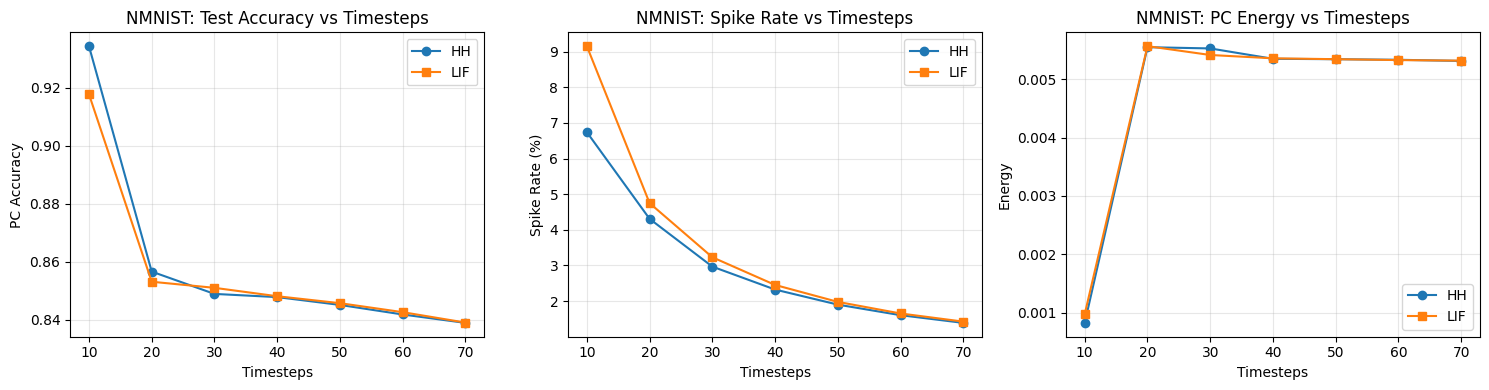

In [16]:
fig, axes = plt.subplots(len(DATASETS), 3, figsize=(15, 4 * len(DATASETS)), squeeze=False)

for i, dataset in enumerate(DATASETS):
    sub = results_df[results_df["dataset"] == dataset]
    for neuron_type, marker in [("hh", "o"), ("lif", "s")]:
        s = sub[sub["neuron_type"] == neuron_type].sort_values("steps_spk")
        if s.empty:
            continue
        axes[i][0].plot(s["steps_spk"], s["test_pc_acc"], marker=marker, label=neuron_type.upper())
        axes[i][1].plot(s["steps_spk"], s["spike_rate_total"] * 100, marker=marker, label=neuron_type.upper())
        axes[i][2].plot(s["steps_spk"], s["pc_energy"], marker=marker, label=neuron_type.upper())

    axes[i][0].set_title(f"{dataset}: Test Accuracy vs Timesteps")
    axes[i][0].set_xlabel("Timesteps"); axes[i][0].set_ylabel("PC Accuracy")
    axes[i][0].legend(); axes[i][0].grid(alpha=0.3)

    axes[i][1].set_title(f"{dataset}: Spike Rate vs Timesteps")
    axes[i][1].set_xlabel("Timesteps"); axes[i][1].set_ylabel("Spike Rate (%)")
    axes[i][1].legend(); axes[i][1].grid(alpha=0.3)

    axes[i][2].set_title(f"{dataset}: PC Energy vs Timesteps")
    axes[i][2].set_xlabel("Timesteps"); axes[i][2].set_ylabel("Energy")
    axes[i][2].legend(); axes[i][2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("hhpc_sweep_plots.png", dpi=150)
plt.show()

## Notes

- `steps_spk` is the spike-simulation length used by both `forward_proxies`
  (network) and `spike_rate_epoch`/`eval_epoch` (evaluation) — it's the
  timestep axis the sweep varies (10–70).
- `T_infer_train` / `T_infer_eval` are separate: how many PC inference
  iterations run *per spike-proxy sample*, unrelated to the timestep sweep.
  Left at the base file's defaults (100 / 50) throughout.
- Each `(dataset, neuron_type, steps_spk)` run uses its own checkpoint file
  under `./ckpts/`, so re-running `run_experiment` for a single point later
  (e.g. to extend the timestep range) won't clobber other results.
- `LIFNeuron` uses its own `lif_thr`/`lif_tau` defaults (1.0 / 0.3) rather
  than sharing HH's `thr` — the two neuron models operate on different
  voltage scales, so this matches how the original ablation code
  instantiated them.